<div style="font-size: 24px; line-height: 1.6;">

# Regression to the Mean: Extremes Drift Back

## Before/after stories are tempting — extreme baselines make them dangerous

![Regression to the Mean: Extremes Drift Back](../images/regression_to_mean.png)

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Takeaway

Functions introduced: `pd.read_pickle`, `sort_values`, `pd.concat`, `corr`.

**Concept learned: extreme selection can make ordinary drift look causal.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

### Imports

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (8, 5)

<div style="font-size: 24px; line-height: 1.6;">

## The story

Students with very low baseline scores tend to improve on a follow-up test, even with no intervention. Students with very high baseline scores tend to drop. This is **regression to the mean** — extremes drift back toward average just because of measurement noise.

</div>

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 1. Load the score dataset

Rows are students with baseline, follow-up, and change. The file is a **pickle** — Python's native serialization format, saved with `df.to_pickle(...)`. `pd.read_pickle()` is the fastest round-trip for Python-only workflows.

*Security note:* never unpickle files from untrusted sources — pickles can execute arbitrary code on load.

</div>

In [2]:
scores = pd.read_pickle("../data/regression_to_mean_scores.pkl")
scores.head()

,student_id,baseline_score,followup_score,change
0,1,71.4,46.8,-24.6
1,2,59.2,89.0,29.8
2,3,58.4,53.0,-5.4
3,4,87.1,76.3,-10.8
4,5,97.1,73.4,-23.7


In [3]:
scores.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      1200 non-null   int64  
 1   baseline_score  1200 non-null   float64
 2   followup_score  1200 non-null   float64
 3   change          1200 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 37.6 KB


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 2. Find extremes with `df.sort_values()`

Sorting reveals the selected extremes.

</div>

In [4]:
lowest = scores.sort_values("baseline_score").head(20)
lowest

,student_id,baseline_score,followup_score,change
1007,1008,3.5,62.5,59.0
80,81,16.9,71.3,54.4
249,250,24.5,54.8,30.3
351,352,25.5,50.6,25.1
932,933,26.3,39.3,13.0
206,207,27.6,75.3,47.7
41,42,28.6,38.5,9.9
42,43,31.8,69.0,37.2
517,518,32.0,70.6,38.6
908,909,32.5,43.1,10.6


In [5]:
highest = scores.sort_values("baseline_score", ascending=False).head(20)
highest

,student_id,baseline_score,followup_score,change
601,602,100.0,91.1,-8.9
1108,1109,100.0,77.9,-22.1
591,592,100.0,100.0,0.0
1097,1098,100.0,73.2,-26.8
1101,1102,100.0,56.4,-43.6
541,542,100.0,94.9,-5.1
116,117,100.0,97.6,-2.4
571,572,100.0,82.5,-17.5
112,113,100.0,100.0,0.0
486,487,100.0,54.8,-45.2


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 3. Compare change in the extreme groups

If regression to the mean is at play, the lowest baselines should *rise* on follow-up and the highest baselines should *fall* — even without any intervention.

</div>

In [6]:
low = scores.sort_values("baseline_score").head(100)
high = scores.sort_values("baseline_score").tail(100)
print(f"Avg change for 100 lowest baselines:  {low['change'].mean():+.2f}")
print(f"Avg change for 100 highest baselines: {high['change'].mean():+.2f}")

Avg change for 100 lowest baselines:  +18.19
Avg change for 100 highest baselines: -12.93


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 4. Build a both-tails group

Concatenate the two extreme tails to compare against the middle.

</div>

In [7]:
extremes = pd.concat([
    scores.sort_values("baseline_score").head(60),
    scores.sort_values("baseline_score").tail(60),
])
extremes.shape

(120, 4)

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 5. Visualize the drift

One scatter of change against baseline shows the whole phenomenon — every student is a dot, and the red dashed line marks 'no change'.

</div>

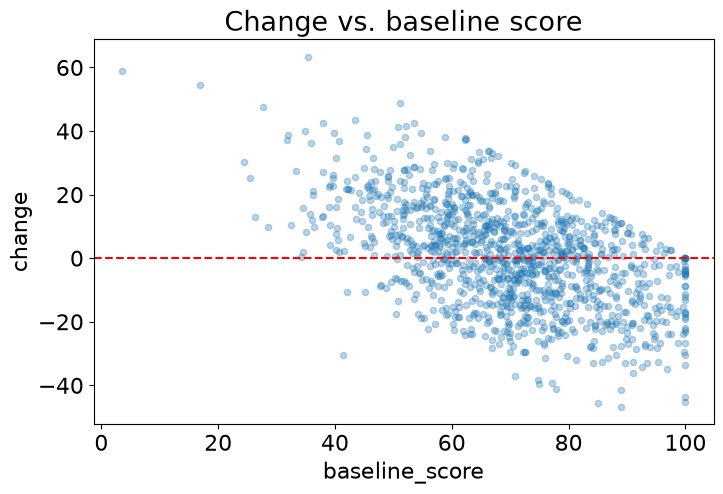

In [8]:
ax = scores.plot(kind="scatter", x="baseline_score", y="change",
                 alpha=0.3, title="Change vs. baseline score")
ax.axhline(0, color="red", linestyle="--")
plt.show()

<div style="font-size: 24px; line-height: 1.6;">

Low baselines mostly rise; high baselines mostly fall. The line of zero change cuts diagonally through the cloud.

</div>

<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 6. Relationships with `df.corr()`

Correlation helps describe the link between baseline, follow-up, and change.

</div>

In [9]:
scores[["baseline_score", "followup_score", "change"]].corr()

,baseline_score,followup_score,change
baseline_score,1.000000,0.438602,-0.527119
followup_score,0.438602,1.000000,0.532496
change,-0.527119,0.532496,1.000000


<div style="font-size: 24px; line-height: 1.6; margin-top: 224px;">

## 7. Change scores need suspicion

`change` is strongly negatively correlated with `baseline` almost automatically: baseline includes random noise that subtracts out in the change.

</div>

In [10]:
scores[["baseline_score", "change"]].corr()

,baseline_score,change
baseline_score,1.000000,-0.527119
change,-0.527119,1.000000


<div style="font-size: 24px; line-height: 1.6;">

## Discussion

- If the lowest-scoring students improved after coaching, what else must be true before claiming the intervention worked?
- What would a fair comparison group look like?

**Real-world examples:** bad sales months rebound, career-best athletes decline, angry customers calm down, extreme stores normalize.

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Why this matters to a data scientist

Any process that *selects on an extreme and then re-measures* will show this drift: the worst-performing stores 'improve' after a management visit, the lowest-engagement users 'respond' to the win-back email, last week's bad model metrics 'recover' after an emergency retrain. In every case, part — sometimes all — of the improvement is regression to the mean, not your intervention.

This is exactly why A/B tests have control groups: the control arm shows how much drift-back happens with *no* intervention, so the treatment only gets credit for the difference. When there is no control group, treat every before/after story that starts from an extreme with suspicion — including your own.

</div>